# Notebook principal
Este notebook contém o fluxo de pré-processamento, treino e explicações SHAP. Execute as células abaixo em ordem.

# Imports

In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report,  confusion_matrix
import shap
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt

# Lendo o dataset

In [16]:
df = pd.read_csv('../Datasets/LMD-2023-dataset.csv')
df = df[df['Label'] != 2]  

C:\Users\vinic\AppData\Local\Temp\ipykernel_14712\4228867806.py:1: DtypeWarning: Columns (40,53,56,57,58,59,60,61,62,65,66,68,69,70,71,72,73,74,75,76,77,78,79,81,82,83,84,85,87,88,89,90,91,92,93) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../Datasets/LMD-2023-dataset.csv')


# Começando o treinamento

In [17]:
# Apenas essas colunas serão usadas para treinar. São as que garantidamente
# aparecem nos logs .evtx E não são identificadores arbitrários do sistema.

# Check if there are duplicated columns (like Execution_ProcessID and ProcessID renaming overlap)
if 'Execution_ProcessID' in df.columns:
    df = df.drop(columns=['Execution_ProcessID']) 

df = df.rename(columns={"ProcessID": "ProcessId", "ParentProcessID": "ParentProcessId", "ThreadID": "ThreadId"})

# Remover colunas duplicadas que surgem com as vezes (se houver variação no CSV)
df = df.loc[:, ~df.columns.duplicated()]

reliable_features = [
    "IntegrityLevel",
    "Image",
    "User",
    "ParentImage",
    "ParentUser"
]

y = df['Label']

# Separando apenas as que confirmamos existirem nos evtx sem identificadores!
X = df[reliable_features].copy()
X.columns


Index(['IntegrityLevel', 'Image', 'User', 'ParentImage', 'ParentUser'], dtype='object')

In [18]:
import joblib

# ---------- Todas as features selecionadas são categóricas (strings) ----------
categorical_features = X.columns.tolist()

# ---------- Label Encoding ----------
X_encoded = X.copy()
encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    # Handle NaN strings if any
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str).fillna(""))
    encoders[col] = le

# Save the encoders! This is crucial so when loading in TestWithLogs we use the EXACT SAME MAPPINGS.
joblib.dump(encoders, "encoders.joblib")
print("Encoders digitais salvos em encoders.joblib")

Encoders digitais salvos em encoders.joblib


In [19]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

rf.fit(X_train, y_train)


RandomForestClassifier(n_jobs=-1, random_state=42)

In [20]:
import joblib

joblib.dump(rf, "modelo_ransomware.joblib")

['modelo_ransomware.joblib']

# Testes da IA

In [21]:
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    322200
           1       0.99      0.98      0.98     22266

    accuracy                           1.00    344466
   macro avg       0.99      0.99      0.99    344466
weighted avg       1.00      1.00      1.00    344466

[[321867    333]
 [   374  21892]]


In [7]:
X_test[:5000]

,Execution_ProcessID,ProcessID,ThreadID,UserID,ProcessId,Image,User,LogonId,TerminalSessionId,IntegrityLevel,...,QueryName,QueryStatus,QueryResults,IsExecutable,NewThreadId,StartAddress,StartModule,StartFunction,Hash,Contents
1296582,5520.0,5520,6800,0,8364.0,215,6,0,0.0,0,...,1,0.0,2,1,0.0,0,1,1,0,2
1699984,0.0,2912,3292,0,5168.0,70,1,0,0.0,0,...,0,0.0,1,0,0.0,0,1,1,0,2
1405593,5520.0,5520,6760,0,4.0,498,9,0,0.0,0,...,1,0.0,2,1,0.0,0,1,1,0,2
977557,5520.0,5520,6760,0,4.0,498,9,0,0.0,0,...,1,0.0,2,1,0.0,0,1,1,0,2
1303521,5520.0,5520,6760,0,4.0,498,9,0,0.0,0,...,1,0.0,2,1,0.0,0,1,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1602204,5520.0,5520,6760,0,4.0,498,9,0,0.0,0,...,1,0.0,2,1,0.0,0,1,1,0,2
830864,5676.0,5676,6840,0,17344.0,215,6,0,0.0,0,...,1,0.0,2,1,0.0,0,1,1,0,2
1433843,5676.0,5676,6824,0,4.0,498,9,0,0.0,0,...,1,0.0,2,1,0.0,0,1,1,0,2
631129,0.0,5520,6760,0,4.0,498,9,0,0.0,0,...,0,0.0,1,0,0.0,0,1,1,0,2


In [22]:

# NÃO MEXER NESSA CÉLULA
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test[:5000])


In [23]:
shap_values.shape

(5000, 5, 2)

instance_idx= 0 class_index= 0
sv shape= (5,) n_features= 5
base_value= 0.9180260285397523


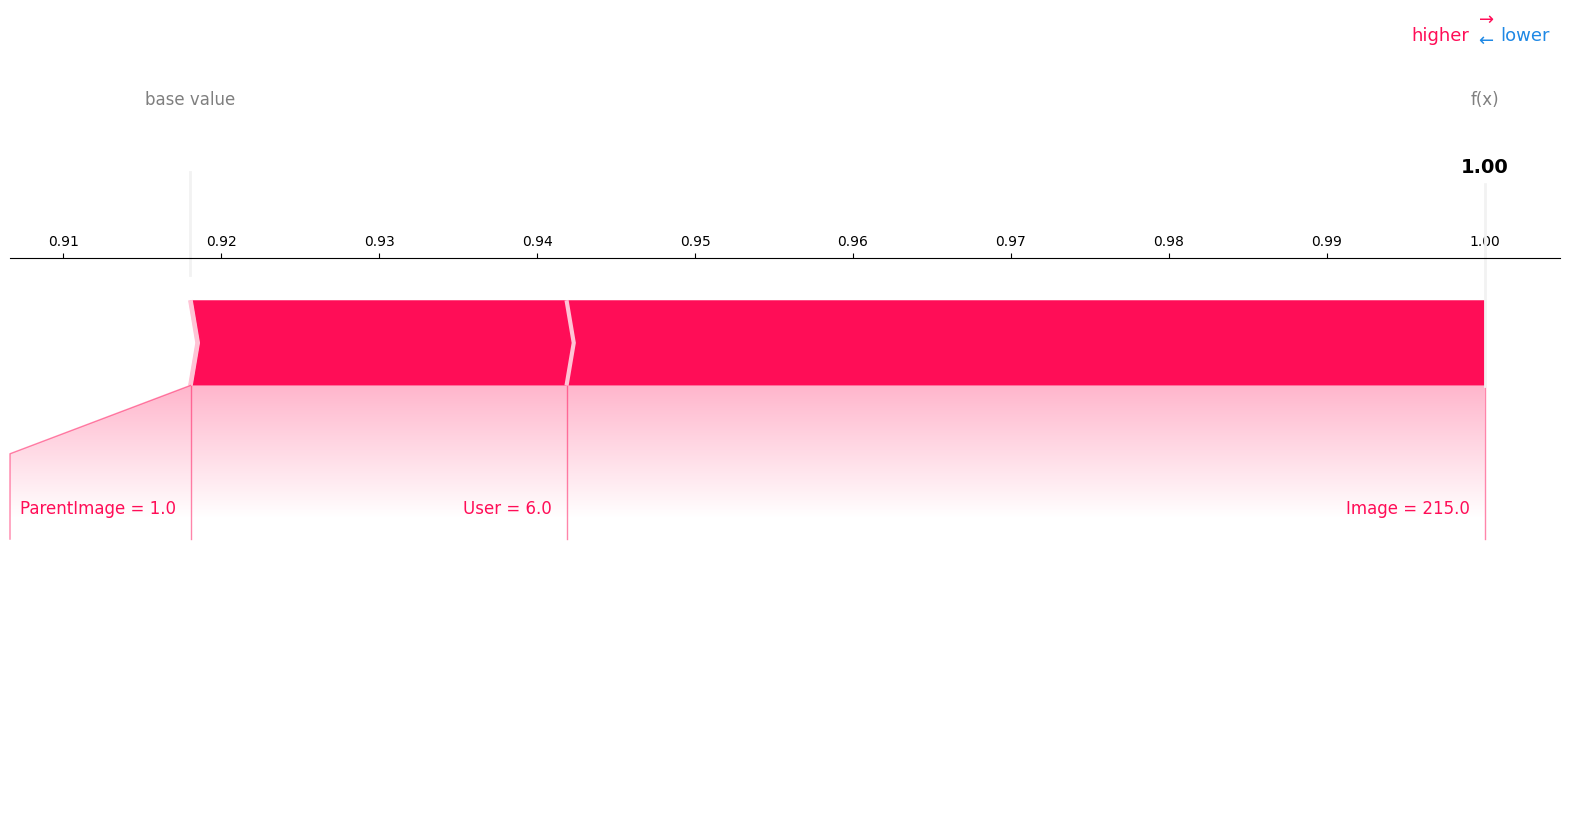

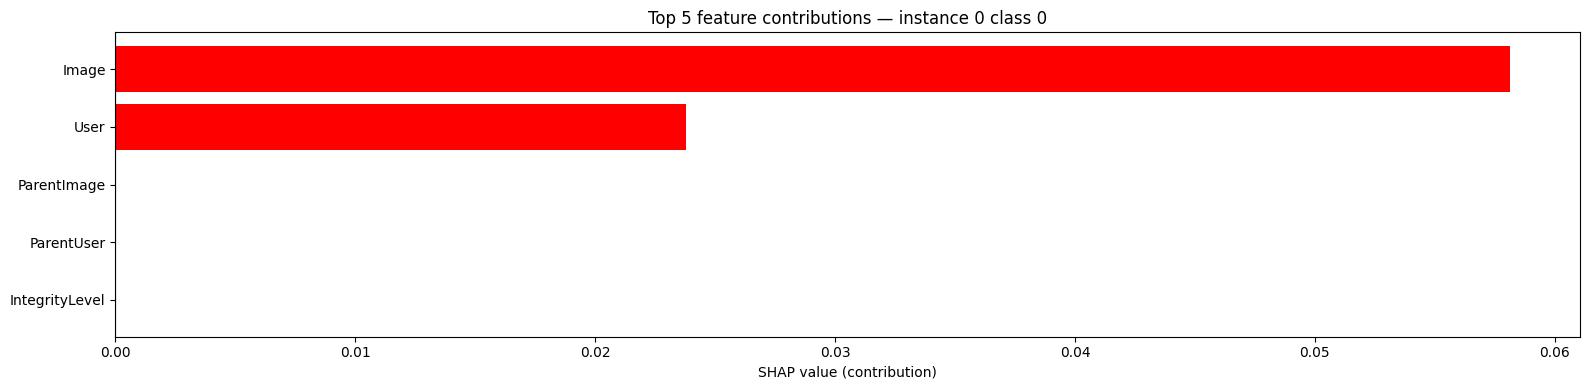

,feature,shap_value
0,Image,0.058141
1,User,0.023799
2,ParentImage,0.000033
3,IntegrityLevel,0.000000
4,ParentUser,0.000000


In [24]:
# === Nova célula final: treinar explainer com primeiras 20000 linhas e plotar force (limitado) ===
import numpy as np
import matplotlib.pyplot as plt

# 1) treinar explainer com as primeiras 20000 linhas do treino
train_sample = 20000
explainer2 = shap.TreeExplainer(rf, data=X_train.iloc[:train_sample])

# 2) calcular shap_values para um subset do X_test (rápido)
sv_all = explainer2.shap_values(X_test.iloc[:100])

# 3) escolher instância e classe (por padrão usa a classe predita pelo modelo)
instance_idx = 0
try:
    probs = rf.predict_proba(X_test.iloc[[instance_idx]])[0]
    class_index = int(np.argmax(probs))
except Exception:
    class_index = 0

# 4) extrair vetor 1D de contribuições (sv) suportando vários formatos
if isinstance(sv_all, list):
    arr = sv_all[class_index] if len(sv_all) > class_index else sv_all[0]
    if hasattr(arr, 'ndim') and arr.ndim == 2:
        sv = arr[instance_idx]
    elif hasattr(arr, 'ndim') and arr.ndim == 3:
        sv = arr[instance_idx].reshape(arr.shape[1], -1).sum(axis=1)
    else:
        sv = np.array(arr[instance_idx]).ravel()
elif isinstance(sv_all, np.ndarray):
    if sv_all.ndim == 3:
        # formato: (n_samples, n_features, n_classes)
        sv = sv_all[instance_idx, :, class_index]
    elif sv_all.ndim == 2:
        sv = sv_all[instance_idx]
    else:
        sv = np.array(sv_all[instance_idx]).ravel()
else:
    sv = np.array(sv_all).ravel()

# 5) preparar features alinhadas
n = sv.shape[0]
feat = X_test.iloc[instance_idx, :n].copy()
if feat.shape[0] != n:
    feat = pd.Series(feat.values[:n], index=[f'feat_{i}' for i in range(n)])

# 6) obter base_value do explainer treinado
ev = explainer2.expected_value
if isinstance(ev, (list, np.ndarray)) and np.size(ev) > 1:
    try:
        base_value = float(np.array(ev).ravel()[class_index])
    except Exception:
        base_value = float(np.array(ev).ravel()[0])
else:
    base_value = float(ev)

print('instance_idx=', instance_idx, 'class_index=', class_index)
print('sv shape=', sv.shape, 'n_features=', n)
print('base_value=', base_value)

# --- Limitar force_plot a um número razoável de features (entre 5 e 10) ---
force_top_k = 8
contribs_full = pd.Series(sv, index=feat.index)
top_force = contribs_full.abs().sort_values(ascending=False).head(force_top_k).index.tolist()

# manter a ordem por magnitude (opcional: mostrar do maior ao menor)
top_force_ordered = contribs_full.loc[top_force].reindex(top_force).index.tolist()
sv_reduced = contribs_full.loc[top_force_ordered].values
feat_reduced = feat.loc[top_force_ordered]

# 7) force_plot apenas com as top features selecionadas (AUMENTEI FIGSIZE HORIZONTAL)
try:
    fig = shap.force_plot(
        base_value,
        sv_reduced,
        feat_reduced,
        feature_names=feat_reduced.index.tolist(),
        matplotlib=True,
        contribution_threshold=0.0,
        figsize=(20, max(1.2, force_top_k * 0.9))  # largura aumentada para menos aperto
    )
    plt.show()
except Exception as e:
    print('force_plot error:', e)

# 8) barplot com as top contribuições (por leitura rápida) - aumentei largura também
bar_top_k = 20
top_feats = contribs_full.abs().sort_values(ascending=False).head(bar_top_k).index
vals = contribs_full.loc[top_feats].reindex(top_feats)
vals_sorted = vals.sort_values()
colors = ['red' if v > 0 else 'blue' for v in vals_sorted.values]
plt.figure(figsize=(16, max(4, len(vals_sorted) * 0.5)))  # largura aumentada
plt.barh(vals_sorted.index, vals_sorted.values, color=colors)
plt.axvline(0, color='k', linewidth=0.8)
plt.xlabel('SHAP value (contribution)')
plt.title(f'Top {len(vals_sorted)} feature contributions — instance {instance_idx} class {class_index}')
plt.tight_layout()
plt.show()

# 9) tabela resumida das features mostradas no barplot
display(pd.DataFrame({'feature': vals.index, 'shap_value': vals.values}).reset_index(drop=True))

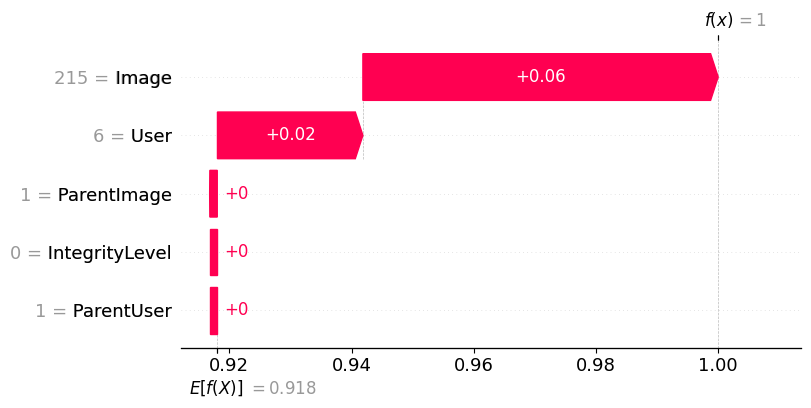

In [25]:
# Waterfall SHAP plot para as top features já selecionadas
import matplotlib.pyplot as plt
try:
    # tenta API moderna (shap.Explanation + shap.plots.waterfall)
    exp = shap.Explanation(
        values=sv_reduced,
        base_values=base_value,
        data=feat_reduced.values,
        feature_names=feat_reduced.index.tolist()
    )
    shap.plots.waterfall(exp, max_display=force_top_k)
    plt.show()
except Exception as e_modern:
    print('modern waterfall failed, trying legacy API -', e_modern)
    try:
        # fallback para versão mais antiga do shap
        shap.plots._waterfall.waterfall_legacy(
            base_value,
            sv_reduced,
            feat_reduced.values,
            feature_names=feat_reduced.index.tolist()
        )
        plt.show()
    except Exception as e_legacy:
        print('waterfall plot failed:', e_legacy)

# fim - se quiser ajustar quantas features aparecem, altere force_top_k na célula anterior

Using class_index = 0 shap_for_plot.shape = (100, 5)


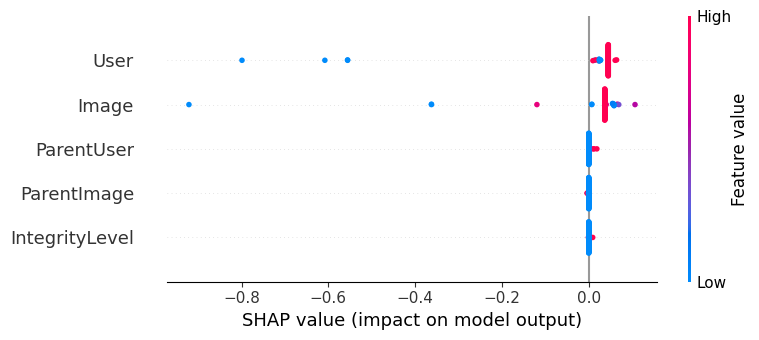

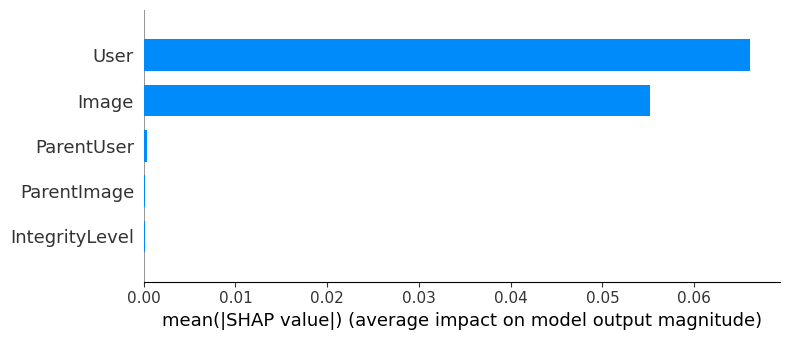

In [26]:
# === Nova célula: SHAP summary plots (dot e bar) ===
import matplotlib.pyplot as plt

# usar mesmo subset usado para sv_all (primeiras 100 linhas calculadas anteriormente)
X_subset = X_test.iloc[:100]

# escolher classe para multiclass: média das probabilidades ou 0 por padrão
try:
    probs_subset = rf.predict_proba(X_subset)
    class_index = int(np.argmax(np.mean(probs_subset, axis=0)))
except Exception:
    class_index = 0

# preparar array de shap values para plot (n_samples, n_features)
if 'sv_all' not in globals():
    raise RuntimeError('sv_all não encontrado — execute a célula que calcula sv_all primeiro')

if isinstance(sv_all, list):
    shap_for_plot = sv_all[class_index]
elif isinstance(sv_all, np.ndarray):
    if sv_all.ndim == 3:
        # formato (n_samples, n_features, n_classes)
        shap_for_plot = sv_all[:, :, class_index]
    else:
        shap_for_plot = sv_all
else:
    shap_for_plot = np.array(sv_all)

print('Using class_index =', class_index, 'shap_for_plot.shape =', getattr(shap_for_plot, 'shape', None))

# alinhar colunas - garantir n_features compatível
if hasattr(X_subset, 'shape') and shap_for_plot.shape[1] != X_subset.shape[1]:
    X_plot = X_subset.iloc[:, :shap_for_plot.shape[1]]
else:
    X_plot = X_subset

# summary dot plot (mais informativo) - ampliar tamanho para legibilidade
plt.figure(figsize=(14,10))
shap.summary_plot(shap_for_plot, X_plot, show=True)

# summary bar plot (média absoluta das contribuições) - complemento
plt.figure(figsize=(12,6))
shap.summary_plot(shap_for_plot, X_plot, plot_type='bar', show=True)

c:\Users\vinic\.virtualenvs\RansonwareData-Oy5xU5Qp\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Instância: 0 — classe predita: 0 (prob=1.0000)

Explicação LIME (feature, contribuição):
User <= 9.00: -0.061681
ParentUser <= 1.00: 0.019309
ParentImage <= 1.00: -0.013237
IntegrityLevel <= 0.00: 0.010982
Image <= 498.00: 0.000000


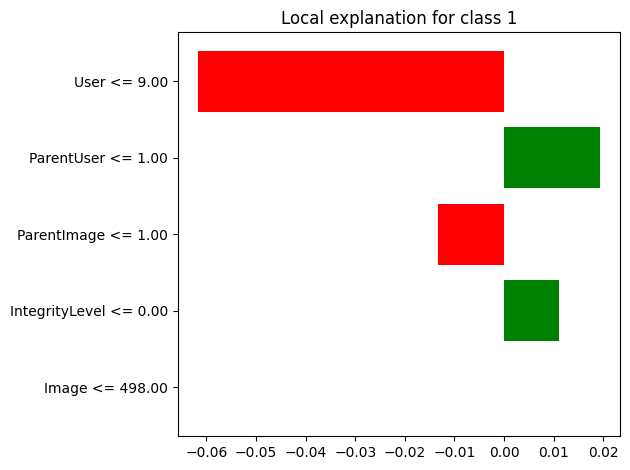

,feature,contribution
0,User <= 9.00,-0.061681
1,ParentUser <= 1.00,0.019309
2,ParentImage <= 1.00,-0.013237
3,IntegrityLevel <= 0.00,0.010982
4,Image <= 498.00,0.000000


In [27]:
# === Nova célula: Interpretação local com LIME ===
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt

# ajuste aqui a instância que quer explicar
instance_idx = 0
num_features = 10  # quantas features mostrar na explicação

# preparar dados para o explainer
X_train_arr = X_train.values if hasattr(X_train, 'values') else X_train
feature_names = X_train.columns.tolist()
class_names = [str(c) for c in (getattr(rf, 'classes_', np.unique(y_train)))]

explainer_lime = LimeTabularExplainer(
    X_train_arr,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification'
)

# função de predição para LIME (usa predict_proba do modelo)
predict_fn = lambda x: rf.predict_proba(x)

# gerar explicação para a instância escolhida
exp = explainer_lime.explain_instance(X_test.iloc[instance_idx].values, predict_fn, num_features=num_features)

# imprimir resumo textual
pred_probs = rf.predict_proba(X_test.iloc[[instance_idx]])[0]
pred_class = int(np.argmax(pred_probs))
print(f'Instância: {instance_idx} — classe predita: {class_names[pred_class]} (prob={pred_probs[pred_class]:.4f})')
print('\nExplicação LIME (feature, contribuição):')
for feat, weight in exp.as_list():
    print(f'{feat}: {weight:.6f}')

# mostrar figura matplotlib gerada pelo LIME
fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

# também montar DataFrame com as contribuições para exportar/incluir no relatório
df_lime = pd.DataFrame(exp.as_list(), columns=['feature', 'contribution'])
display(df_lime)